# Optimization Methods — Project 1: Results

This notebook presents the experimental results for each method implemented in `optimization_methods/`. Each section loads the iteration history saved by the corresponding script in `experiments/<method>/` and shows: (1) a table with the first 10 iterations, and (2) a convergence plot (iteration vs. error with respect to the known exact solution).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6g}")

## Steepest Descent

Function: $f(x_1,x_2) = (x_1-d)^4 + (x_1-2dx_2)^2$, $d=3$, $x_0=[1,3]$.
Exact solution: $x^* = (3,\ 0.5)$, $f(x^*)=0$.

In [2]:
sd_history = pd.read_csv("experiments/steepest_descent/history.csv")

sd_table = sd_history.head(10).rename(columns={
    "k": "Iteration",
    "f": "f(x)",
    "grad_norm": "||grad f(x)||",
    "error": "||x - x*||",
})
sd_table.set_index("Iteration")

,x1,x2,f(x),||grad f(x)||,||x - x*||
Iteration,,,,,
0,1,3,305,214.411,3.20156
1,2.03125,-0.1875,10.8427,37.9694,1.18791
2,1.98944,0.404297,1.23331,7.24047,1.01508
3,2.14571,0.240669,1.025,8.49073,0.892782
4,2.16275,0.372238,0.496376,2.62947,0.846941
5,2.31831,0.319232,0.378291,4.85699,0.70525
6,2.32552,0.394779,0.20882,1.41207,0.68264
7,2.40762,0.362411,0.1775,2.82159,0.608146
8,2.41333,0.406128,0.119012,0.899664,0.594134


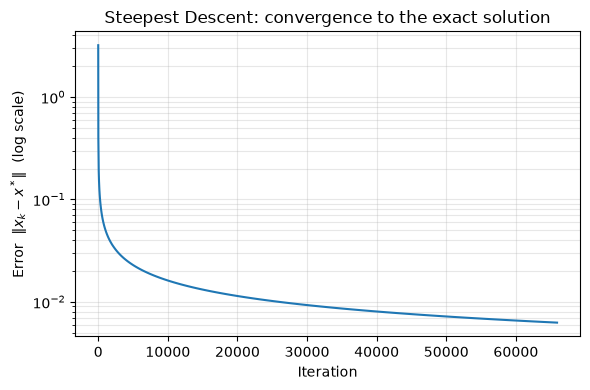

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(sd_history["k"], sd_history["error"])
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Error  $\|x_k - x^*\|$  (log scale)")
ax.set_title("Steepest Descent: convergence to the exact solution")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

In [4]:
final = sd_history.iloc[-1]
print(f"Converged in {len(sd_history)} iterations")
print(f"Final point: x = ({final['x1']:.6f}, {final['x2']:.6f})")
print(f"Final f(x)        = {final['f']:.3e}")
print(f"Final ||grad f(x)|| = {final['grad_norm']:.3e}")
print(f"Final ||x - x*||     = {final['error']:.3e}")

Converged in 65917 iterations
Final point: x = (2.993825, 0.498971)
Final f(x)        = 1.453e-09
Final ||grad f(x)|| = 9.992e-07
Final ||x - x*||     = 6.260e-03


## Newton's Method

Same function, same $x_0=[1,3]$, same exact solution $x^*=(3,\ 0.5)$.
Note: $\nabla^2 f(x^*)$ is singular (positive semi-definite, not positive
definite), so the classical quadratic-convergence guarantee of Newton's
Method does not strictly apply here (see discussion below the plot).

In [5]:
newton_history = pd.read_csv("experiments/newton/history.csv")

newton_table = newton_history.head(10).rename(columns={
    "k": "Iteration",
    "f": "f(x)",
    "grad_norm": "||grad f(x)||",
    "error": "||x - x*||",
})
newton_table.set_index("Iteration")

,x1,x2,f(x),||grad f(x)||,||x - x*||
Iteration,,,,,
0,1,3,305,214.411,3.20156
1,1.66667,0.277778,3.16049,9.48148,1.35173
2,2.11111,0.351852,0.624295,2.80933,0.90115
3,2.40741,0.401235,0.123318,0.832393,0.600767
4,2.60494,0.434156,0.024359,0.246635,0.400511
5,2.73663,0.456104,0.00481166,0.0730771,0.267007
6,2.82442,0.470736,0.000950451,0.0216525,0.178005
7,2.88294,0.480491,0.000187743,0.00641554,0.11867
8,2.92196,0.486994,3.70851e-05,0.0019009,0.0791133


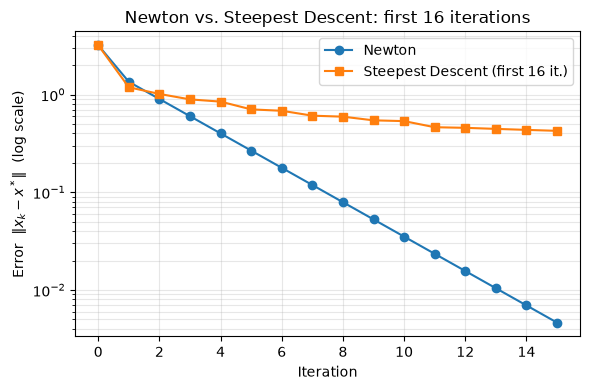

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(newton_history["k"], newton_history["error"], marker="o", label="Newton")
ax.semilogy(sd_history["k"][:16], sd_history["error"][:16], marker="s", label="Steepest Descent (first 16 it.)")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Error  $\|x_k - x^*\|$  (log scale)")
ax.set_title("Newton vs. Steepest Descent: first 16 iterations")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

In [7]:
final = newton_history.iloc[-1]
ratios = (newton_history["error"] / newton_history["error"].shift(1)).dropna()
print(f"Converged in {len(newton_history)} iterations")
print(f"Final point: x = ({final['x1']:.6f}, {final['x2']:.6f})")
print(f"Final f(x)          = {final['f']:.3e}")
print(f"Final ||grad f(x)|| = {final['grad_norm']:.3e}")
print(f"Final ||x - x*||    = {final['error']:.3e}")
print(f"Steady-state error ratio ||e_(k+1)|| / ||e_k|| = {ratios.iloc[-1]:.4f}  (linear, not quadratic)")

Converged in 16 iterations
Final point: x = (2.995433, 0.499239)
Final f(x)          = 4.352e-10
Final ||grad f(x)|| = 3.811e-07
Final ||x - x*||    = 4.630e-03
Steady-state error ratio ||e_(k+1)|| / ||e_k|| = 0.6667  (linear, not quadratic)
